# Introduction: The interacting multiple model Kalman filter
The output from this notebook will be used to provide answers for this lesson's practice
quiz. It implements the interacting multiple model Kalman filter.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Don't change the next line, which sets the random-number "seed"; otherwise, the results from
% executing the IMM may be different from those expected by the quiz.
randn("seed",5);

In [3]:
% Set up model 1 for mode 1
% NCV model, one dimensional, T=1
% Start with continuous-time; convert to discrete-time
Ac = [0 1; 0 0]; Bc = [0; 1]; Swc = 2;
Z = [-Ac Bc*Swc*Bc'; zeros(size(Ac)) Ac'];
C = expm(Z*1);
A1 = C(3:4,3:4)';
Sw1 = A1*C(1:2,3:4);
B1 = [1^2/2; 1]; C1 = [1 0];
Sv1 = 0.25;

% Set up model 2 for mode 2
% NCP model, one dimensional, T=1
% Start with continuous-time; convert to discrete-time
Ac = [0 0; 0 0]; Bc = [1; 0]; Swc = 0.5;
Z = [-Ac Bc*Swc*Bc'; zeros(size(Ac)) Ac'];
C = expm(Z*1);
A2 = C(3:4,3:4)';
Sw2 = A2*C(1:2,3:4);
B2 = [1; 0]; C2 = [1 0 ];
Sv2 = 0.1;

% Populate the immData and immState structures
immData = [];
immData.txprob = [0.95 0.05; 0.05 0.95];
immData.A(:,:,1) = A1; 
immData.A(:,:,2) = A2;
immData.B(:,:,1) = B1;
immData.B(:,:,2) = B2;
immData.C(:,:,1) = C1;
immData.C(:,:,2) = C2;
immData.D(:,:,1) = 0;
immData.D(:,:,2) = 0;
immData.Sw(:,:,1) = Sw1;
immData.Sw(:,:,2) = Sw2;
immData.Sv(:,:,1) = Sv1;
immData.Sv(:,:,2) = Sv2;

immState = [];
immState.mode = [0.8; 0.2];  % a-priori likelihood for each mode
immState.X = [0 0; 0.3 0.3]; % initialize both modes to same state estimate
immState.SX = [0.1 0.1; 0 0; 0 0; 0.1 0.1];
immState.xhat = [0; 0];      % these two are outputs, not inputs, but I'll set
immState.SigmaX = [0.1 0; 0 0.1]; % them anyway

In [4]:
% A function to update the IMM every iteration
function immState = iterIMM(uold,unew,z,immState,immData)

  modes = size(immData.A,3);  
  nx = size(immData.A,1);
 
  % Interaction step
  % 1) Compute cbar = sum(p(i,j)*mu(i,k-1))
  cbar = immData.txprob'*immState.mode;
  % 2) Compute mu(i|j,k-1) = 1/cbar * p(i,j)*mu(i,k-1)
  modeij = immData.txprob.*(immState.mode*(cbar.^(-1))');
  modeij(isnan(modeij)) = 0; % take care of impossible final states
  % 3) Compute xhat(mod)
  x0 = immState.X*modeij; 
  % 4) Compute Sigma(mod). [Fixed error in Bar-Shalom IMM code here]
  Sx0 = immState.SX; Sx1 = immState.SX; % reserve space for Sx0,Sx1
  for j = 1:modes,
    xk1 = immState.X(:,j); Sx = xk1*xk1'; Sx0(:,j) = Sx(:);
    xk1 = x0(:,j); Sx = xk1*xk1'; Sx1(:,j) = Sx(:);
  end
  Sx0 = (immState.SX + Sx0)*modeij - Sx1; % verified

  % Filtering step
  Lambda = zeros(size(cbar)); Sx = zeros(nx);
  for j = 1:modes,
    % 0) Set up variables for this filter
    xhat = x0(:,j); Sx(:) = Sx0(:,j);
    A = immData.A(:,:,j); B = immData.B(:,:,j);      
    C = immData.C(:,:,j); D = immData.D(:,:,j);
    Sw = immData.Sw(:,:,j); Sv = immData.Sv(:,:,j);
    % 1) State estimate time update
    xhat = A*xhat + B*uold;
    % 2) State covariance time update 
    Sx = A*Sx*A' + Sw;
    % 3) Output estimate
    zhat = C*xhat + D*unew;
    % 4) Filter gain matrix
    Py = (C*Sx*C'+Sv); L = Sx*C'/Py;
    % 5) State estimate measurement update
    immState.X(:,j) = xhat + L*(z-zhat);
    % 6) State covariance measurement update
    Sx = Sx - L*Py*L'; immState.SX(:,j) = Sx(:);
    Lambda(j) = max(1e-9,exp(-0.5 * ((z-zhat)^2/Py)) / ... 
        sqrt(2*pi*Py)); % much faster than normpdf
  end

  % Combination step 
  % 1) Compute PMF of being in mode j: mu(j,k)
  immState.mode = Lambda.*cbar; 
  immState.mode = immState.mode/sum(immState.mode);
  % 2) Compute composite state estimate
  immState.xhat = immState.X*immState.mode;
  % 3) Compute composite covariance estimate
  modeSx = immState.SX;
  for j=1:modes
    xk1=immState.X(:,j)-immState.xhat; 
    Sx=xk1*xk1'; modeSx(:,j)=Sx(:);
  end
  immState.SigmaX(:) = (immState.SX+modeSx)*immState.mode;
end  

In [5]:
% Generate the true system data
xtrue = zeros([2,201]);
z = zeros(1,200);

% Use "model 1" for the first 100 iterations
for k = 1:99
  xtrue(:,k+1) = A1*xtrue(:,k) + chol(Sw1,'lower')*randn([2 1]);
  z(k) = C1*xtrue(:,k) + sqrt(Sv1)*randn(1);
end

% Use "model 2" for the final 100 iterations
for k = 100:200
  xtrue(:,k+1) = A2*xtrue(:,k) + sqrt(Sw2)*randn([2 1]);
  z(k) = C2*xtrue(:,k) + sqrt(Sv2)*randn(1);
end

In [6]:
% Run the IMM on these data
xhatstore = zeros([2,200]);
modestore = zeros([2,200]);
sigmastore = zeros([4,200]);
for k = 1:200
  immState = iterIMM(0,0,z(k),immState,immData);
  xhatstore(:,k) = immState.xhat;
  sigmastore(:,k) = immState.SigmaX(:);
  modestore(:,k) = immState.mode;
end

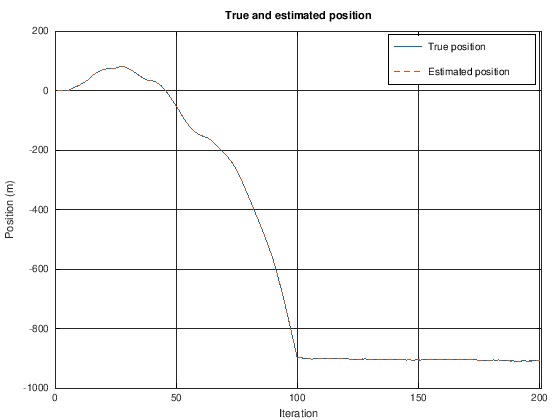

In [7]:
plot(1:200,xtrue(1,1:200)); hold on;
plot(1:200,xhatstore(1,:),'--');
title('True and estimated position');
xlabel('Iteration'); ylabel('Position (m)'); xlim([0 201]); grid on
legend('True position','Estimated position','location','northeast');

bndErrFrac = 0


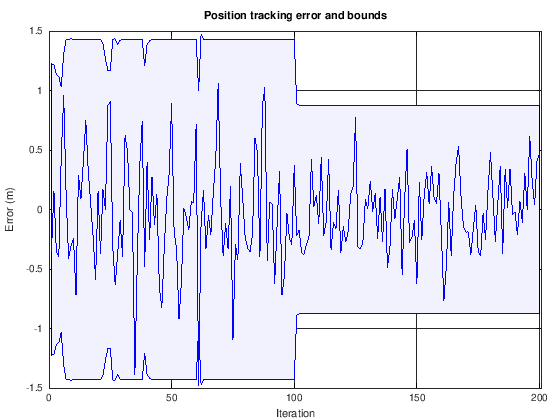

In [8]:
t = 1:200; t2 = [t,fliplr(t)];
xerr = xtrue(1,1:200)-xhatstore(1,:); 
bnds = 3*sqrt(sigmastore(1,:)); bnds2 = [bnds,-fliplr(bnds)];
fill(t2,bnds2,'b',"FaceAlpha",0.05); hold on
plot(xtrue(1,1:200)-xhatstore(1,:),'b'); hold on;
title('Position tracking error and bounds');
xlabel('Iteration'); ylabel('Error (m)');
axis([0 201 -1.5 1.5]); grid on
plot(3*sqrt(sigmastore(1,:)),'b','linewidth',0.5);
plot(-3*sqrt(sigmastore(1,:)),'b','linewidth',0.5);
bndErrFrac = length(find(abs(xerr>bnds)))/length(bnds)*100

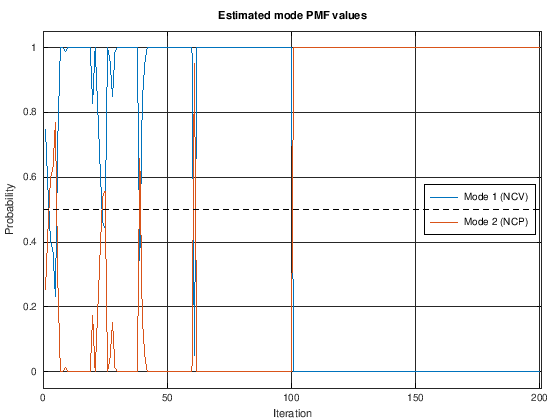

In [9]:
plot(modestore');
hold on; h = plot([0 201],[0.5 0.5],'k--','linewidth',0.5);
title('Estimated mode PMF values');
xlabel('Iteration');
ylabel('Probability');
legend('Mode 1 (NCV)','Mode 2 (NCP)','location','east');
axis([0 201 -0.05 1.05]); grid on